# MAPPO v4 — 1M (Kaggle Version)
**Environment:** `simple_spread_v3` — N=3 agents, discrete actions, max_cycles=50

**Algorithm:** MAPPO — Multi-Agent PPO with Centralised Critic (CTDE)
- Shared actor: local obs → discrete action (5-dim) via Softmax
- Centralised critic: global obs (54-dim) → V-value, deeper 512→512→256
- On-policy: rollout buffer, 16 episodes per update
- Results saved to /kaggle/working/ and zipped for download

## Fixes vs original (Colab) version:
- All save paths → `/kaggle/working/` (no bare filenames, no `/content/`)
- Removed Google Drive / Colab-specific cells
- Install cell: only pettingzoo (torch/numpy already on Kaggle)
- Added GPU check + SAVE_DIR setup cell
- Added zip + download cell (same pattern as MADDPG 500K/1M)
- Added verify output files cell
- Checkpoints saved to `checkpoint_N/` subfolders (organised)
- `.pkl` normalizer files also included in zip

In [1]:
# CELL 1 — Install (Kaggle already has torch/numpy/matplotlib)
!pip install -q pettingzoo==1.24.3 gymnasium==0.29.1 supersuit==3.9.3
print("✅ Install complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 24.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.29.3 requires gymnasium==1.2.0, but you have gymnasium 0.29.1 which is incompatible.
kaggle-environments 1.29.3 requires pettingzoo==1.24.0, but you have pettingzoo 1.24.3 which is incompatible.
shimmy 2.0.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
✅ Install

In [2]:
# CELL 2 — GPU Check + Save Directory
import torch, os
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU — go to Settings (right panel) → Accelerator → GPU P100")

# Kaggle output directory — all files saved here persist after session ends
SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

Torch  : 2.10.0+cpu
CUDA   : False
Save dir: /kaggle/working


In [3]:
# CELL 3 — Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import time, os, pickle, zipfile, shutil
print("Imports done.")

Imports done.


In [4]:
# CELL 4 — Environment Setup
from pettingzoo.mpe import simple_spread_v3

env = simple_spread_v3.parallel_env(
    N=3,
    local_ratio=0.5,
    max_cycles=50,
    continuous_actions=False
)
obs, _ = env.reset()

AGENTS           = ["agent_0", "agent_1", "agent_2"]
NUM_AGENTS       = len(AGENTS)
OBS_DIM          = env.observation_space(env.agents[0]).shape[0]
ACTION_DIM       = env.action_space(env.agents[0]).n
GLOBAL_STATE_DIM = OBS_DIM * NUM_AGENTS

print(f"Agents={NUM_AGENTS} | ObsDim={OBS_DIM} | Actions={ACTION_DIM} | GlobalDim={GLOBAL_STATE_DIM}")

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
error: XDG_RUNTIME_DIR not set in the environment.


Agents=3 | ObsDim=18 | Actions=5 | GlobalDim=54


In [5]:
# CELL 5 — Running Normalizer (Welford online algorithm)
class RunningNorm:
    def __init__(self, shape=(), clip=5.0, eps=1e-8):
        self.shape = (shape,) if isinstance(shape, int) else shape
        self.mean  = np.zeros(self.shape, np.float64)
        self.var   = np.ones(self.shape,  np.float64)
        self.count = eps
        self.clip  = clip
        self.eps   = eps

    def update(self, x):
        x = np.asarray(x, np.float64).reshape(self.shape)
        self.count += 1
        delta       = x - self.mean
        self.mean  += delta / self.count
        self.var   += delta * (x - self.mean)

    @property
    def std(self):
        return np.sqrt(self.var / self.count + self.eps)

    def normalize(self, x):
        x_norm = (np.asarray(x, np.float64) - self.mean) / self.std
        return np.clip(x_norm, -self.clip, self.clip).astype(np.float32)

    def normalize_scalar(self, x):
        return float(np.clip(x / self.std[0], -self.clip, self.clip))


obs_norm = RunningNorm(shape=OBS_DIM, clip=5.0)
ret_norm = RunningNorm(shape=1,       clip=5.0)

print("Normalizers ready.")

Normalizers ready.


In [6]:
# CELL 6 — Actor Network (shared across agents)
def ortho_init(layer, gain=np.sqrt(2)):
    nn.init.orthogonal_(layer.weight, gain=gain)
    nn.init.zeros_(layer.bias)
    return layer


class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.fc1  = ortho_init(nn.Linear(obs_dim, hidden))
        self.ln1  = nn.LayerNorm(hidden)
        self.fc2  = ortho_init(nn.Linear(hidden, hidden))
        self.ln2  = nn.LayerNorm(hidden)
        self.head = ortho_init(nn.Linear(hidden, act_dim), gain=0.01)

    def forward(self, x):
        x = torch.tanh(self.ln1(self.fc1(x)))
        x = torch.tanh(self.ln2(self.fc2(x)))
        return torch.softmax(self.head(x), dim=-1)


actor = Actor(OBS_DIM, ACTION_DIM)
print(actor)

Actor(
  (fc1): Linear(in_features=18, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=5, bias=True)
)


In [7]:
# CELL 7 — Centralised Critic (deeper: 512→512→256)
# Critic sees global state (all agents obs concatenated)
class Critic(nn.Module):
    def __init__(self, state_dim, h1=512, h2=512, h3=256):
        super().__init__()
        self.fc1  = ortho_init(nn.Linear(state_dim, h1))
        self.ln1  = nn.LayerNorm(h1)
        self.fc2  = ortho_init(nn.Linear(h1, h2))
        self.ln2  = nn.LayerNorm(h2)
        self.fc3  = ortho_init(nn.Linear(h2, h3))
        self.ln3  = nn.LayerNorm(h3)
        self.head = ortho_init(nn.Linear(h3, 1), gain=1.0)

    def forward(self, x):
        x = torch.tanh(self.ln1(self.fc1(x)))
        x = torch.tanh(self.ln2(self.fc2(x)))
        x = torch.tanh(self.ln3(self.fc3(x)))
        return self.head(x)


critic = Critic(GLOBAL_STATE_DIM)
print(critic)

Critic(
  (fc1): Linear(in_features=54, out_features=512, bias=True)
  (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (ln3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=1, bias=True)
)


In [8]:
# CELL 8 — Hyperparameters  (1M)
TOTAL_STEPS          = 1_000_000

GAMMA                = 0.99
GAE_LAMBDA           = 0.95
CLIP_EPS             = 0.2
VALUE_CLIP           = None         # Disabled: normalised returns handle scale

PPO_EPOCHS           = 10
MINI_BATCH           = 512
EPISODES_PER_UPDATE  = 16           # 16 × 50 × 3 = 2400 actor samples/update

ENTROPY_COEF         = 0.05         # Fixed — no annealing
VALUE_COEF           = 0.5

ACTOR_LR             = 3e-4
CRITIC_LR            = 1e-3
ACTOR_GRAD_CLIP      = 0.5
CRITIC_GRAD_CLIP     = 0.5

CRITIC_WARMUP_STEPS  = 5
CRITIC_WARMUP_UNTIL  = 100_000

SAVE_EVERY           = 100_000

print("Hyperparameters set — 1M run.")

Hyperparameters set — 1M run.


In [9]:
# CELL 9 — Optimizers & Schedulers
actor_opt  = optim.Adam(actor.parameters(),  lr=ACTOR_LR,  eps=1e-5)
critic_opt = optim.Adam(critic.parameters(), lr=CRITIC_LR, eps=1e-5)

timesteps_done = 0

def linear_schedule(t):
    return max(1.0 - t / TOTAL_STEPS, 0.05)

actor_sched  = optim.lr_scheduler.LambdaLR(
    actor_opt,  lr_lambda=lambda _: linear_schedule(timesteps_done))
critic_sched = optim.lr_scheduler.LambdaLR(
    critic_opt, lr_lambda=lambda _: linear_schedule(timesteps_done))

print("Optimizers and schedulers ready.")

Optimizers and schedulers ready.


In [10]:
# CELL 10 — Rollout Buffer
class Buffer:
    __slots__ = ('obs', 'states', 'actions', 'logprobs',
                 'rewards', 'dones', 'values')

    def __init__(self):
        for s in self.__slots__:
            setattr(self, s, [])

    def clear(self):
        for s in self.__slots__:
            getattr(self, s).clear()


buf = Buffer()
print("Buffer ready.")

Buffer ready.


In [11]:
# CELL 11 — GAE Computation
def compute_gae(rewards, values, dones):
    adv_list, gae = [], 0.0
    vals = values + [0.0]
    for t in reversed(range(len(rewards))):
        mask  = 1.0 - dones[t]
        delta = rewards[t] + GAMMA * vals[t+1] * mask - vals[t]
        gae   = delta + GAMMA * GAE_LAMBDA * mask * gae
        adv_list.insert(0, gae)
    returns = [a + v for a, v in zip(adv_list, values)]
    return adv_list, returns


def gae_over_buffer():
    all_adv, all_ret = [], []
    ep_start = 0
    for t, d in enumerate(buf.dones):
        if d == 1.0:
            adv, ret = compute_gae(
                buf.rewards[ep_start:t+1],
                buf.values[ep_start:t+1],
                buf.dones[ep_start:t+1]
            )
            all_adv.extend(adv)
            all_ret.extend(ret)
            ep_start = t + 1
    return all_adv, all_ret

In [12]:
# CELL 12 — Action Selection & Value Estimation
@torch.no_grad()
def select_actions(obs_dict):
    actions, logprobs = {}, {}
    for ag in AGENTS:
        obs_norm.update(obs_dict[ag])
        x    = torch.FloatTensor(obs_norm.normalize(obs_dict[ag])).unsqueeze(0)
        dist = Categorical(actor(x))
        a    = dist.sample()
        actions[ag]  = a.item()
        logprobs[ag] = dist.log_prob(a).item()
    return actions, logprobs


@torch.no_grad()
def get_value(obs_dict):
    state = np.concatenate([
        obs_norm.normalize(obs_dict[ag]) for ag in AGENTS
    ])
    return critic(torch.FloatTensor(state).unsqueeze(0)).item()


def make_global_state(obs_dict):
    return np.concatenate([
        obs_norm.normalize(obs_dict[ag]) for ag in AGENTS
    ])

In [13]:
# CELL 13 — Collect Episodes
def collect(n_eps=EPISODES_PER_UPDATE):
    buf.clear()
    raw_ep_rewards = []

    for _ in range(n_eps):
        obs, _ = env.reset()
        ep_raw = 0.0
        done   = False

        while not done:
            gs               = make_global_state(obs)
            actions, logprbs = select_actions(obs)
            value            = get_value(obs)

            next_obs, rewards, terms, truncs, _ = env.step(actions)

            r_mean = float(np.mean(list(rewards.values())))
            ep_raw += r_mean

            ret_norm.update(np.array([r_mean]))
            r_norm = ret_norm.normalize_scalar(r_mean)

            done = all(terms.values()) or all(truncs.values())

            buf.obs.append(obs)
            buf.states.append(gs)
            buf.actions.append(actions)
            buf.logprobs.append(logprbs)
            buf.rewards.append(r_norm)
            buf.dones.append(float(done))
            buf.values.append(value)

            obs = next_obs

        raw_ep_rewards.append(ep_raw)

    return raw_ep_rewards


# Smoke test
test = collect(1)
print(f"Test ep reward: {test[0]:.2f} | Buffer size: {len(buf.rewards)}")

Test ep reward: -50.03 | Buffer size: 50


In [14]:
# CELL 14 — Build Training Tensors
def build_tensors(advantages, returns):
    states_t   = torch.FloatTensor(np.stack(buf.states))
    returns_t  = torch.FloatTensor(returns).unsqueeze(1)
    oldvals_t  = torch.FloatTensor(buf.values).unsqueeze(1)

    obs_l, act_l, lp_l, adv_l = [], [], [], []
    for obs_d, act_d, lp_d, adv in zip(
        buf.obs, buf.actions, buf.logprobs, advantages
    ):
        for ag in AGENTS:
            obs_l.append(obs_norm.normalize(obs_d[ag]))
            act_l.append(act_d[ag])
            lp_l.append(lp_d[ag])
            adv_l.append(adv)

    actor_obs_t = torch.FloatTensor(np.stack(obs_l))
    actions_t   = torch.LongTensor(act_l)
    old_lp_t    = torch.FloatTensor(lp_l)
    adv_t       = torch.FloatTensor(adv_l)

    return actor_obs_t, actions_t, old_lp_t, adv_t, states_t, returns_t, oldvals_t

In [15]:
# CELL 15 — Single Mini-Batch Update
def minibatch_update(mb_obs, mb_act, mb_lp, mb_adv,
                     mb_states, mb_ret, mb_oldv,
                     actor_update=True):

    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

    # ---- Critic ----
    v_pred = critic(mb_states)
    c_loss = VALUE_COEF * nn.functional.mse_loss(v_pred, mb_ret)

    critic_opt.zero_grad()
    c_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), CRITIC_GRAD_CLIP)
    critic_opt.step()

    if not actor_update:
        return 0.0, c_loss.item(), 0.0

    # ---- Actor ----
    probs   = actor(mb_obs)
    dist    = Categorical(probs)
    new_lp  = dist.log_prob(mb_act)
    entropy = dist.entropy().mean()

    ratio = torch.exp(new_lp - mb_lp)
    s1    = ratio * mb_adv
    s2    = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * mb_adv
    a_loss = -torch.min(s1, s2).mean() - ENTROPY_COEF * entropy

    actor_opt.zero_grad()
    a_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), ACTOR_GRAD_CLIP)
    actor_opt.step()

    return a_loss.item(), c_loss.item(), entropy.item()

In [16]:
# CELL 16 — PPO Epoch Loop (with optional critic warmup)
def ppo_update(tensors, critic_warmup=False):
    actor_obs, actions, old_lp, adv, states, returns, oldvals = tensors
    N = actor_obs.shape[0]
    a_losses, c_losses, entropies = [], [], []

    if critic_warmup:
        for _ in range(CRITIC_WARMUP_STEPS):
            idx = torch.randperm(states.shape[0])
            for s in range(0, states.shape[0], MINI_BATCH):
                ci = idx[s:s+MINI_BATCH]
                ai = ci.repeat_interleave(NUM_AGENTS)
                ai = ai[:MINI_BATCH]
                minibatch_update(
                    mb_obs=actor_obs[ai], mb_act=actions[ai],
                    mb_lp=old_lp[ai],    mb_adv=adv[ai],
                    mb_states=states[ci], mb_ret=returns[ci],
                    mb_oldv=oldvals[ci],
                    actor_update=False
                )

    for _ in range(PPO_EPOCHS):
        idx_a = torch.randperm(N)
        for s in range(0, N, MINI_BATCH):
            ai = idx_a[s:s+MINI_BATCH]
            ci = ai // NUM_AGENTS
            al, cl, ent = minibatch_update(
                mb_obs=actor_obs[ai], mb_act=actions[ai],
                mb_lp=old_lp[ai],    mb_adv=adv[ai].clone(),
                mb_states=states[ci], mb_ret=returns[ci],
                mb_oldv=oldvals[ci],
                actor_update=True
            )
            a_losses.append(al)
            c_losses.append(cl)
            entropies.append(ent)

    return np.mean(a_losses), np.mean(c_losses), np.mean(entropies)

In [17]:
# CELL 17 — Full Smoke Test
ep_rs = collect(EPISODES_PER_UPDATE)
adv, ret = gae_over_buffer()
tens = build_tensors(adv, ret)
al, cl, ent = ppo_update(tens, critic_warmup=False)
print(f"Smoke test OK — mean ep: {np.mean(ep_rs):.2f} | "
      f"actor_loss: {al:.4f} | critic_loss: {cl:.4f} | entropy: {ent:.4f}")

Smoke test OK — mean ep: -45.65 | actor_loss: -0.0941 | critic_loss: 411.7054 | entropy: 1.6028


In [18]:
# CELL 18 — MAIN TRAINING LOOP  (1M)
timesteps_done = 0
best_avg100    = -float('inf')
start_time     = time.time()

all_ep_rewards = []
a_loss_hist    = []
c_loss_hist    = []
ent_hist       = []
update_n       = 0

print(f"MAPPO v4 1M — starting...")
print(f"Total steps: {TOTAL_STEPS:,} | Episodes/update: {EPISODES_PER_UPDATE} | Mini-batch: {MINI_BATCH}")
print("-" * 90)

while timesteps_done < TOTAL_STEPS:

    # ── 1. Collect ──────────────────────────────────────────────────────
    raw_rewards = collect(EPISODES_PER_UPDATE)
    ep_steps    = len(buf.rewards)

    # ── 2. GAE ──────────────────────────────────────────────────────────
    advantages, returns = gae_over_buffer()

    # ── 3. Build tensors ────────────────────────────────────────────────
    tensors = build_tensors(advantages, returns)

    # ── 4. Update ───────────────────────────────────────────────────────
    do_warmup = (timesteps_done < CRITIC_WARMUP_UNTIL)
    al, cl, ent = ppo_update(tensors, critic_warmup=do_warmup)
    update_n   += 1

    # ── 5. Step schedulers ──────────────────────────────────────────────
    timesteps_done += ep_steps
    actor_sched.step()
    critic_sched.step()

    # ── 6. Logging ──────────────────────────────────────────────────────
    all_ep_rewards.extend(raw_rewards)
    a_loss_hist.append(al)
    c_loss_hist.append(cl)
    ent_hist.append(ent)

    avg100  = float(np.mean(all_ep_rewards[-100:]))
    ep_mean = float(np.mean(raw_rewards))

    # ── 7. Save best models ─────────────────────────────────────────────
    if avg100 > best_avg100:
        best_avg100 = avg100
        torch.save(actor.state_dict(),  f"{SAVE_DIR}/best_actor.pth")
        torch.save(critic.state_dict(), f"{SAVE_DIR}/best_critic.pth")

    # ── 8. Checkpoint every SAVE_EVERY steps ────────────────────────────
    if timesteps_done % SAVE_EVERY < ep_steps:
        ckpt_dir = f"{SAVE_DIR}/checkpoint_{timesteps_done}"
        os.makedirs(ckpt_dir, exist_ok=True)
        torch.save(actor.state_dict(),  f"{ckpt_dir}/actor.pth")
        torch.save(critic.state_dict(), f"{ckpt_dir}/critic.pth")
        print(f"\n[Checkpoint] {timesteps_done:,} steps | Best Avg100: {best_avg100:.2f}\n")

    # ── 9. Progress every 5 updates ─────────────────────────────────────
    if update_n % 5 == 0:
        elapsed = time.time() - start_time
        eta_str = f"{(elapsed/timesteps_done)*(TOTAL_STEPS-timesteps_done)/60:.0f}m" if timesteps_done > 0 else "--"
        print(
            f"Ep {len(all_ep_rewards):6d} | "
            f"Reward {ep_mean:8.2f} | "
            f"Avg100 {avg100:8.2f} | "
            f"Steps {timesteps_done:>9,} | "
            f"Ent {ent:.3f} | "
            f"ALoss {al:.4f} | "
            f"CLoss {cl:.4f} | "
            f"LR {actor_opt.param_groups[0]['lr']:.5f} | "
            f"ETA {eta_str}"
        )

# ── Training complete ─────────────────────────────────────────────────────
total_time = time.time() - start_time
torch.save(actor.state_dict(),  f"{SAVE_DIR}/final_actor.pth")
torch.save(critic.state_dict(), f"{SAVE_DIR}/final_critic.pth")
print(f"\nTraining complete — {total_time/60:.1f} min | Best Avg100: {best_avg100:.2f}")

MAPPO v4 1M — starting...
Total steps: 1,000,000 | Episodes/update: 16 | Mini-batch: 512
------------------------------------------------------------------------------------------
Ep     80 | Reward   -53.16 | Avg100   -55.07 | Steps     4,000 | Ent 1.572 | ALoss -0.0966 | CLoss 123.6912 | LR 0.00030 | ETA 75m
Ep    160 | Reward   -59.50 | Avg100   -52.25 | Steps     8,000 | Ent 1.518 | ALoss -0.0985 | CLoss 35.3754 | LR 0.00030 | ETA 75m
Ep    240 | Reward   -55.49 | Avg100   -56.52 | Steps    12,000 | Ent 1.522 | ALoss -0.0937 | CLoss 22.4810 | LR 0.00030 | ETA 74m
Ep    320 | Reward   -57.00 | Avg100   -55.38 | Steps    16,000 | Ent 1.499 | ALoss -0.0947 | CLoss 18.0375 | LR 0.00030 | ETA 73m
Ep    400 | Reward   -52.48 | Avg100   -56.51 | Steps    20,000 | Ent 1.477 | ALoss -0.0936 | CLoss 14.9550 | LR 0.00029 | ETA 73m
Ep    480 | Reward   -61.39 | Avg100   -53.04 | Steps    24,000 | Ent 1.490 | ALoss -0.0955 | CLoss 42.4864 | LR 0.00029 | ETA 73m
Ep    560 | Reward   -52.11 | Avg

In [19]:
# CELL 19 — Final Metrics
print("=" * 55)
print("  MAPPO v4 — 1M — Final Metrics")
print("=" * 55)
print(f"  Mean Reward   : {np.mean(all_ep_rewards):.2f}")
print(f"  Std  Reward   : {np.std(all_ep_rewards):.2f}")
print(f"  Max  Reward   : {np.max(all_ep_rewards):.2f}")
print(f"  Min  Reward   : {np.min(all_ep_rewards):.2f}")
print(f"  Best Avg100   : {best_avg100:.2f}")
print(f"  Total Episodes: {len(all_ep_rewards)}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 55)

  MAPPO v4 — 1M — Final Metrics
  Mean Reward   : -43.90
  Std  Reward   : 12.71
  Max  Reward   : -13.66
  Min  Reward   : -161.43
  Best Avg100   : -36.94
  Total Episodes: 20000
  Training Time : 67.4 min


In [20]:
# CELL 20 — Greedy Evaluation (best model)
@torch.no_grad()
def evaluate(n_eps=100):
    actor.load_state_dict(torch.load(f"{SAVE_DIR}/best_actor.pth"))
    actor.eval()
    rewards = []

    for _ in range(n_eps):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            actions = {}
            for ag in AGENTS:
                x = torch.FloatTensor(
                    obs_norm.normalize(obs[ag])
                ).unsqueeze(0)
                actions[ag] = actor(x).argmax(dim=-1).item()
            obs, rews, terms, truncs, _ = env.step(actions)
            ep_r += float(np.mean(list(rews.values())))
            done  = all(terms.values()) or all(truncs.values())
        rewards.append(ep_r)

    actor.train()
    return rewards


eval_rews = evaluate(100)
print("=" * 55)
print("  Greedy Evaluation — 100 episodes")
print("=" * 55)
print(f"  Mean Reward   : {np.mean(eval_rews):.2f}")
print(f"  Std  Reward   : {np.std(eval_rews):.2f}")
print(f"  Max  Reward   : {np.max(eval_rews):.2f}")
print(f"  Min  Reward   : {np.min(eval_rews):.2f}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 55)

  Greedy Evaluation — 100 episodes
  Mean Reward   : -37.45
  Std  Reward   : 11.43
  Max  Reward   : -13.78
  Min  Reward   : -75.28
  Training Time : 67.4 min


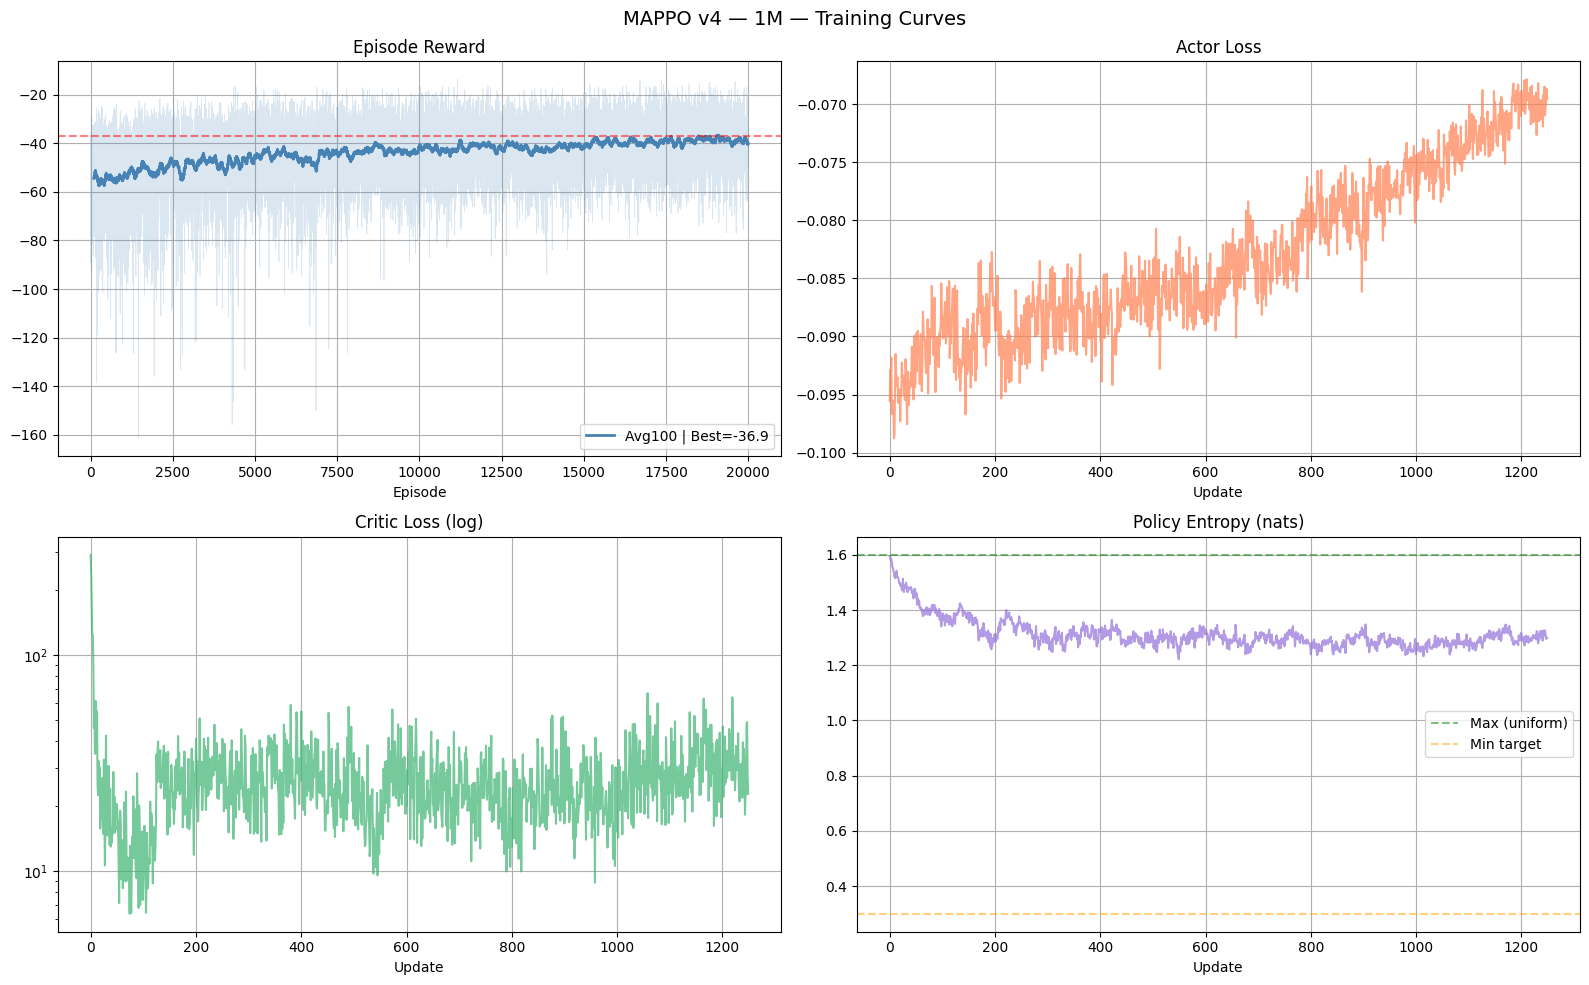

Plot saved → /kaggle/working/mappo_1M_curves.png


In [21]:
# CELL 21 — Training Curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("MAPPO v4 — 1M — Training Curves", fontsize=14)

ax = axes[0, 0]
ax.plot(all_ep_rewards, alpha=0.2, color='steelblue', lw=0.5)
w = 100
if len(all_ep_rewards) >= w:
    ma = np.convolve(all_ep_rewards, np.ones(w)/w, mode='valid')
    ax.plot(range(w-1, len(all_ep_rewards)), ma, color='steelblue', lw=2,
            label=f'Avg100 | Best={best_avg100:.1f}')
ax.axhline(best_avg100, color='red', ls='--', alpha=0.5)
ax.set_title("Episode Reward"); ax.set_xlabel("Episode")
ax.legend(); ax.grid(True)

ax = axes[0, 1]
ax.plot(a_loss_hist, color='coral', alpha=0.7)
ax.set_title("Actor Loss"); ax.set_xlabel("Update"); ax.grid(True)

ax = axes[1, 0]
cl_arr = np.array(c_loss_hist)
cl_arr = np.where(cl_arr > 0, cl_arr, 1e-6)
ax.semilogy(cl_arr, color='mediumseagreen', alpha=0.7)
ax.set_title("Critic Loss (log)"); ax.set_xlabel("Update"); ax.grid(True)

ax = axes[1, 1]
ax.plot(ent_hist, color='mediumpurple', alpha=0.7)
ax.axhline(1.6, color='green',  ls='--', alpha=0.5, label='Max (uniform)')
ax.axhline(0.3, color='orange', ls='--', alpha=0.5, label='Min target')
ax.set_title("Policy Entropy (nats)")
ax.set_xlabel("Update"); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/mappo_1M_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved → {SAVE_DIR}/mappo_1M_curves.png")

In [22]:
# CELL 22 — Save Normalizer States (required for inference)
with open(f"{SAVE_DIR}/obs_norm.pkl", "wb") as f:
    pickle.dump({'mean': obs_norm.mean, 'var': obs_norm.var,
                 'count': obs_norm.count}, f)

with open(f"{SAVE_DIR}/ret_norm.pkl", "wb") as f:
    pickle.dump({'mean': ret_norm.mean, 'var': ret_norm.var,
                 'count': ret_norm.count}, f)

print("Normalizer states saved.")
print(f"  obs_norm: mean≈{obs_norm.mean.mean():.3f}, std≈{obs_norm.std.mean():.3f}")
print(f"  ret_norm: mean≈{ret_norm.mean[0]:.3f}, std≈{ret_norm.std[0]:.3f}")

Normalizer states saved.
  obs_norm: mean≈0.084, std≈1.072
  ret_norm: mean≈-0.878, std≈0.330


In [23]:
# CELL 23 — Save results (Kaggle version)
# Collects all .pth / .png / .pkl files + checkpoint folders into a single zip

results_dir = f"{SAVE_DIR}/MAPPO_1M_results"
os.makedirs(results_dir, exist_ok=True)

copied = []

# Copy top-level .pth, .png, .pkl files
for f in sorted(os.listdir(SAVE_DIR)):
    src = os.path.join(SAVE_DIR, f)
    if os.path.isfile(src) and f.endswith(('.pth', '.png', '.pkl')):
        dst = os.path.join(results_dir, f)
        shutil.copy(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        copied.append((f, size_kb))
        print(f"  {f:50s} {size_kb:7.1f} KB")

# Copy checkpoint subfolders
for entry in sorted(os.listdir(SAVE_DIR)):
    src = os.path.join(SAVE_DIR, entry)
    if os.path.isdir(src) and entry.startswith('checkpoint_'):
        dst_sub = os.path.join(results_dir, entry)
        shutil.copytree(src, dst_sub, dirs_exist_ok=True)
        n_pth = len([x for x in os.listdir(dst_sub) if x.endswith('.pth')])
        print(f"  {entry}/  ({n_pth} .pth files)")
        copied.append((entry, 0))

# Zip everything
zip_path = f"{SAVE_DIR}/MAPPO_1M.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, results_dir)
            zf.write(full, arcname)

zip_size = os.path.getsize(zip_path) / (1024*1024)
print(f"\n{'='*60}")
print(f"  Saved {len(copied)} items → {results_dir}")
print(f"  Zip: MAPPO_1M.zip ({zip_size:.1f} MB)")
print(f"{'='*60}")
print("\nTo download:")
print("  Kaggle → right panel → Output tab → MAPPO_1M.zip")
print("  Then upload zip to Google Drive manually")

  best_actor.pth                                       289.0 KB
  best_critic.pth                                     1665.1 KB
  final_actor.pth                                      289.0 KB
  final_critic.pth                                    1665.1 KB
  mappo_1M_curves.png                                  299.4 KB
  obs_norm.pkl                                           0.5 KB
  ret_norm.pkl                                           0.2 KB
  checkpoint_100000/  (2 .pth files)
  checkpoint_1000000/  (2 .pth files)
  checkpoint_200000/  (2 .pth files)
  checkpoint_300000/  (2 .pth files)
  checkpoint_400000/  (2 .pth files)
  checkpoint_500000/  (2 .pth files)
  checkpoint_600000/  (2 .pth files)
  checkpoint_700000/  (2 .pth files)
  checkpoint_800000/  (2 .pth files)
  checkpoint_900000/  (2 .pth files)

  Saved 17 items → /kaggle/working/MAPPO_1M_results
  Zip: MAPPO_1M.zip (21.5 MB)

To download:
  Kaggle → right panel → Output tab → MAPPO_1M.zip
  Then upload zip to Google Drive

In [24]:
# CELL 24 — Verify output files (run anytime to check)

print(f"Files in {SAVE_DIR}:")
all_files = []
for f in sorted(os.listdir(SAVE_DIR)):
    full = os.path.join(SAVE_DIR, f)
    if os.path.isfile(full) and f.endswith(('.pth', '.png', '.pkl', '.zip')):
        size = os.path.getsize(full) / 1024
        all_files.append(f)
        print(f"  {f:50s} {size:7.1f} KB")
    elif os.path.isdir(full) and f.startswith('checkpoint_'):
        n = len([x for x in os.listdir(full) if x.endswith('.pth')])
        print(f"  {f}/  ({n} .pth files)")
        all_files.append(f)
print(f"\nTotal items: {len(all_files)}")
print("\nTo download: Kaggle → Output tab (right panel) → click download icon")

Files in /kaggle/working:
  MAPPO_1M.zip                                       22013.8 KB
  best_actor.pth                                       289.0 KB
  best_critic.pth                                     1665.1 KB
  checkpoint_100000/  (2 .pth files)
  checkpoint_1000000/  (2 .pth files)
  checkpoint_200000/  (2 .pth files)
  checkpoint_300000/  (2 .pth files)
  checkpoint_400000/  (2 .pth files)
  checkpoint_500000/  (2 .pth files)
  checkpoint_600000/  (2 .pth files)
  checkpoint_700000/  (2 .pth files)
  checkpoint_800000/  (2 .pth files)
  checkpoint_900000/  (2 .pth files)
  final_actor.pth                                      289.0 KB
  final_critic.pth                                    1665.1 KB
  mappo_1M_curves.png                                  299.4 KB
  obs_norm.pkl                                           0.5 KB
  ret_norm.pkl                                           0.2 KB

Total items: 18

To download: Kaggle → Output tab (right panel) → click download icon
